### Introduction About the Data :

**The dataset** The goal is to predict `price` of given diamond (Regression Analysis).

There are 10 independent variables (including `id`):

* `id` : unique identifier of each diamond
* `carat` : Carat (ct.) refers to the unique unit of weight measurement used exclusively to weigh gemstones and diamonds.
* `cut` : Quality of Diamond Cut
* `color` : Color of Diamond
* `clarity` : Diamond clarity is a measure of the purity and rarity of the stone, graded by the visibility of these characteristics under 10-power magnification.
* `depth` : The depth of diamond is its height (in millimeters) measured from the culet (bottom tip) to the table (flat, top surface)
* `table` : A diamond's table is the facet which can be seen when the stone is viewed face up.
* `x` : Diamond X dimension
* `y` : Diamond Y dimension
* `x` : Diamond Z dimension

Target variable:
* `price`: Price of the given Diamond.

Dataset Source Link :
[https://www.kaggle.com/competitions/playground-series-s3e8/data?select=train.csv](https://www.kaggle.com/competitions/playground-series-s3e8/data?select=train.csv)

In [2]:
import pandas as pd
import numpy as  np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("C:/Users/Mohit/Desktop/Data Science and Machine Learning/Project/notebooks/data/gemstone.csv")

In [4]:
df.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,193573.0,96786.000000,55879.856166,0.0,48393.00,96786.00,145179.00,193572.00
carat,193573.0,0.790688,0.462688,0.2,0.40,0.70,1.03,3.50
depth,193573.0,61.820574,1.081704,52.1,61.30,61.90,62.40,71.60
table,193573.0,57.227675,1.918844,49.0,56.00,57.00,58.00,79.00
x,193573.0,5.715312,1.109422,0.0,4.70,5.70,6.51,9.65
y,193573.0,5.720094,1.102333,0.0,4.71,5.72,6.51,10.01
z,193573.0,3.534246,0.688922,0.0,2.90,3.53,4.03,31.30
price,193573.0,3969.155414,4034.374138,326.0,951.00,2401.00,5408.00,18818.00


In [6]:
df.isnull().sum()

id         0
carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

In [7]:
df.duplicated().sum()

0

In [8]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       193573 non-null  int64  
 1   carat    193573 non-null  float64
 2   cut      193573 non-null  object 
 3   color    193573 non-null  object 
 4   clarity  193573 non-null  object 
 5   depth    193573 non-null  float64
 6   table    193573 non-null  float64
 7   x        193573 non-null  float64
 8   y        193573 non-null  float64
 9   z        193573 non-null  float64
 10  price    193573 non-null  int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 45.3 MB


In [9]:
df.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


In [10]:
df.drop(['id'] , axis=1 , inplace=True)

In [11]:
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


In [12]:
columns=list(df.columns)
columns

['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z', 'price']

In [13]:
df.dtypes

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
x          float64
y          float64
z          float64
price        int64
dtype: object

In [14]:
numeric_cols=[col for col in columns if df[col].dtypes!='object']
categorical_col=[col for col in columns if df[col].dtypes=='object']

print(numeric_cols)
print(categorical_col)

['carat', 'depth', 'table', 'x', 'y', 'z', 'price']
['cut', 'color', 'clarity']


In [15]:
df[categorical_col].describe().T

,count,unique,top,freq
cut,193573,5,Ideal,92454
color,193573,7,G,44391
clarity,193573,8,SI1,53272


In [16]:
df['cut'].value_counts()

cut
Ideal        92454
Premium      49910
Very Good    37566
Good         11622
Fair          2021
Name: count, dtype: int64

In [17]:
df['color'].value_counts()

color
G    44391
E    35869
F    34258
H    30799
D    24286
I    17514
J     6456
Name: count, dtype: int64

In [18]:
df['clarity'].value_counts()

clarity
SI1     53272
VS2     48027
VS1     30669
SI2     30484
VVS2    15762
VVS1    10628
IF       4219
I1        512
Name: count, dtype: int64

Text(0, 0.5, 'density')

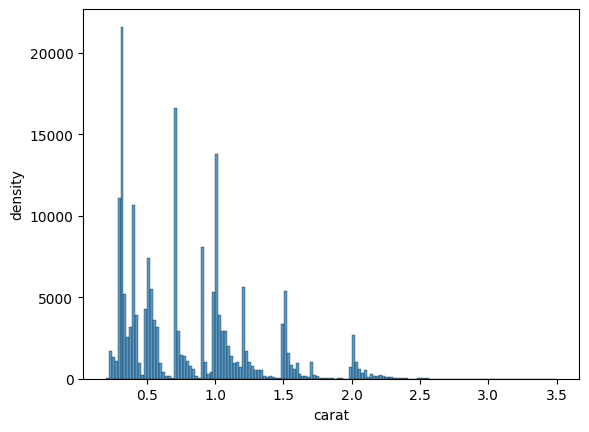

In [19]:
sns.histplot(df['carat'])
plt.xlabel('carat')
plt.ylabel('density')

In [20]:
len(numeric_cols)

7

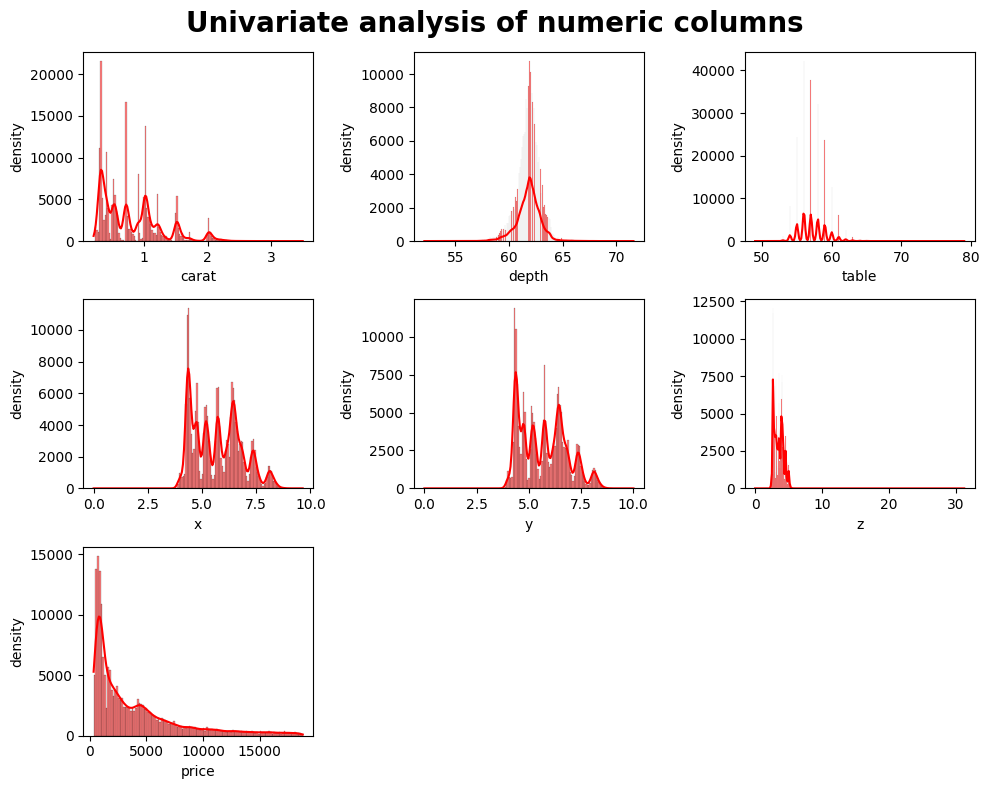

In [21]:
plt.figure(figsize=(10 , 8))
plt.suptitle("Univariate analysis of numeric columns" , fontsize=20 , fontweight='bold')

for i in range(0 , len(numeric_cols)):
    plt.subplot(3 , 3 , i+1)
    sns.histplot(df[numeric_cols[i]] , kde=True , color='red')
    plt.xlabel(numeric_cols[i])
    plt.ylabel('density')
    plt.tight_layout()
    

<Axes: xlabel='color', ylabel='count'>

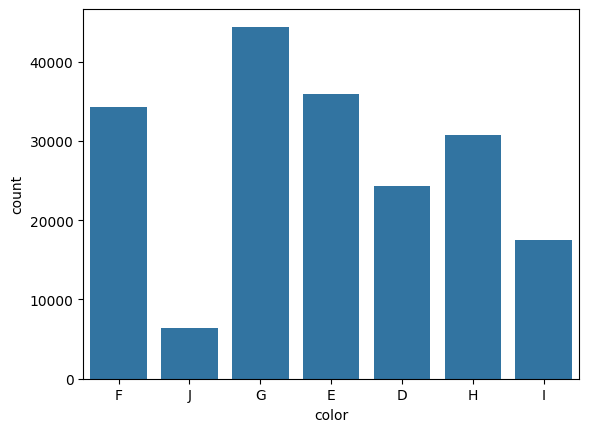

In [22]:
sns.countplot(data=df  , x='color')

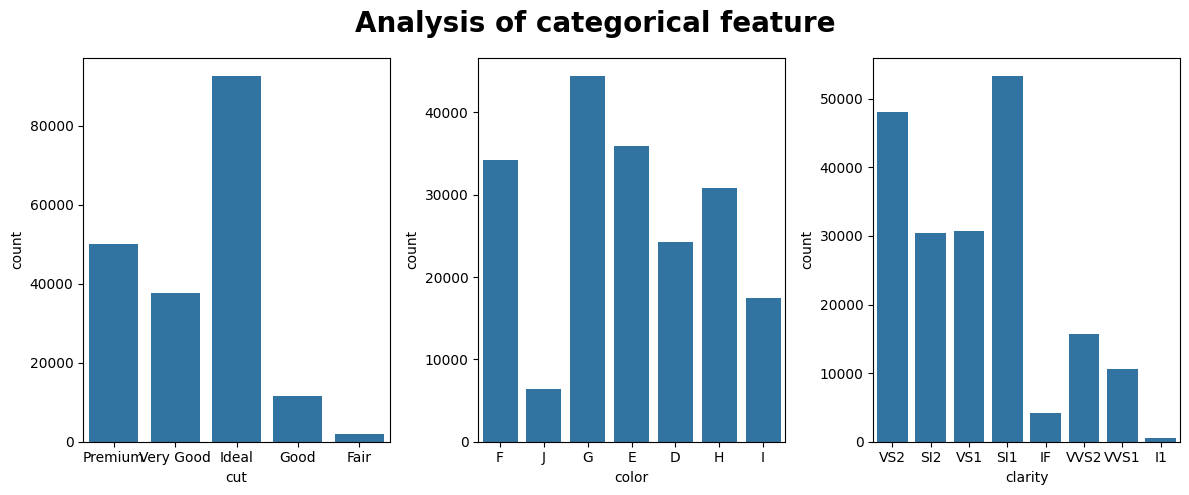

In [23]:
plt.figure(figsize=(12 , 5))
plt.suptitle("Analysis of categorical feature" , fontsize=20 , fontweight='bold')

for i in range(0 , len(categorical_col)):
    
    plt.subplot(1 , 3 , i+1)
    sns.countplot(data = df , x=categorical_col[i])
    plt.tight_layout()

<Axes: >

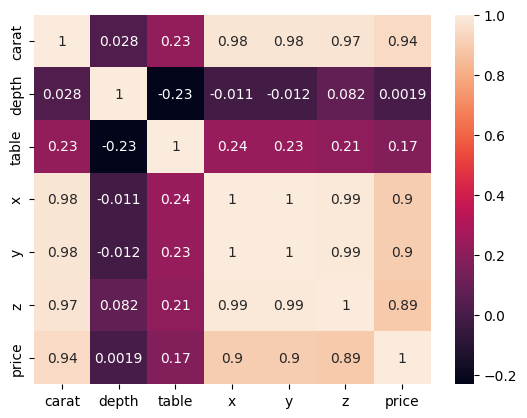

In [24]:
sns.heatmap(df[numeric_cols].corr() , annot=True)

In [25]:
df['cut'].unique()

array(['Premium', 'Very Good', 'Ideal', 'Good', 'Fair'], dtype=object)

In [26]:
cut_map={'Fair' : 1 , "Good":2 , "Very Good":3 , "Premium":4 , "Ideal":5 }

In [27]:
df['clarity'].unique()

array(['VS2', 'SI2', 'VS1', 'SI1', 'IF', 'VVS2', 'VVS1', 'I1'],
      dtype=object)

In [28]:
clarity_map = {"I1":1,"SI2":2 ,"SI1":3 ,"VS2":4 , "VS1":5 , "VVS2":6 , "VVS1":7 ,"IF":8}

In [29]:
color_map = {"D":1 ,"E":2 ,"F":3 , "G":4 ,"H":5 , "I":6, "J":7}

In [30]:
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


In [31]:
X=df.iloc[: , :-1]
y=df.iloc[: , -1]

In [32]:
# Define the custom ranking for each ordinal variable
cut_categories = ['Fair', 'Good', 'Very Good','Premium','Ideal']
color_categories = ['D', 'E', 'F', 'G', 'H', 'I', 'J']
clarity_categories = ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']

In [33]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

In [34]:
numeric_cols.pop()

'price'

In [35]:
numeric_cols

['carat', 'depth', 'table', 'x', 'y', 'z']

In [36]:
num_pipeline=Pipeline(
    steps=[
        ('imputer' , SimpleImputer(strategy='median')) ,
        ('scaler' , StandardScaler())
    ]
)

In [37]:
categorical_pipeline=Pipeline(
    steps=[
        ('imputer' , SimpleImputer(strategy='most_frequent')),
        ('ordinalencoding' , OrdinalEncoder(categories=[cut_categories , color_categories , clarity_categories])) ,
        ('scaler' , StandardScaler())
    ]
)

In [38]:
preprocessor=ColumnTransformer([
    ('num_pipeline' , num_pipeline , numeric_cols),
    ('categorical_pipeline' , categorical_pipeline , categorical_col)
])

In [39]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.30 , random_state=42)

In [40]:
X_train

,carat,cut,color,clarity,depth,table,x,y,z
11504,0.41,Ideal,E,VVS2,60.6,56.0,4.85,4.80,2.93
95284,1.23,Very Good,H,VS1,59.9,59.0,6.91,7.01,4.19
184777,1.70,Premium,H,VS2,62.0,58.0,7.61,7.66,4.74
5419,0.33,Ideal,F,VVS1,61.2,56.0,4.47,4.44,2.73
45466,0.33,Very Good,I,SI1,62.1,58.0,4.41,4.45,2.75
...,...,...,...,...,...,...,...,...,...
119879,0.50,Very Good,E,SI1,60.2,61.0,5.11,5.15,3.09
103694,1.91,Very Good,F,SI1,62.3,62.0,7.85,7.79,4.87
131932,1.22,Premium,G,VS2,62.8,58.0,6.82,6.74,4.26
146867,0.31,Very Good,G,VVS1,61.1,56.0,4.37,4.40,2.67


In [41]:
X_train=pd.DataFrame(preprocessor.fit_transform(X_train) , columns=preprocessor.get_feature_names_out())
X_test=pd.DataFrame(preprocessor.transform(X_test) , columns=preprocessor.get_feature_names_out())

In [42]:
X_test

,num_pipeline__carat,num_pipeline__depth,num_pipeline__table,num_pipeline__x,num_pipeline__y,num_pipeline__z,categorical_pipeline__cut,categorical_pipeline__color,categorical_pipeline__clarity
0,-0.629077,0.258230,-0.120630,-0.600482,-0.581521,-0.572248,0.874100,-1.552614,-0.648127
1,2.605374,-2.148014,-0.120630,2.126042,2.198832,1.959219,-1.137644,0.294987,-1.314417
2,-1.125026,-1.222536,0.921902,-1.374347,-1.414721,-1.469110,-0.131772,-0.936747,2.017037
3,-1.017211,-0.574701,0.921902,-1.158385,-1.161138,-1.194265,-0.131772,1.526720,2.017037
4,0.858771,0.628421,-0.641897,0.947248,0.985258,1.004495,0.874100,0.910853,-0.648127
...,...,...,...,...,...,...,...,...,...
58067,0.255007,0.535873,0.921902,0.416340,0.369414,0.425874,-1.137644,1.526720,-1.314417
58068,-0.607514,0.535873,-0.641897,-0.528495,-0.554351,-0.499920,0.874100,-1.552614,0.018164
58069,-0.823144,-0.019414,-0.641897,-0.834441,-0.862273,-0.847093,0.874100,0.294987,2.017037
58070,0.901897,-0.667249,1.443168,1.046230,0.967145,0.932167,-0.131772,1.526720,-0.648127


In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.ensemble import AdaBoostRegressor

In [44]:
models={
    'LinearRegression' : LinearRegression() ,
    'Lasso' : Lasso() ,
    'Ridge' : Ridge() ,
    'Elastic Net' : ElasticNet() , 
    'Decession Tree Regressor' : DecisionTreeRegressor() ,
    'SVR' : SVR() ,
    'RandomForestRegressor' : RandomForestRegressor() ,
    'GradientBoostingRegressor' : GradientBoostingRegressor() ,
    'AdaBoostRegressor' : AdaBoostRegressor()
}

In [45]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score 

In [46]:
def evaluate_model(actual , predicted):
    mae=mean_absolute_error(actual , predicted) 
    mse=mean_squared_error(actual ,predicted) 
    r2=r2_score(actual , predicted) 
    rmse=np.sqrt(mse)
    return mae , rmse  , r2

In [47]:
y_test

14868      1355
165613    14691
96727       844
145593      707
118689     5797
          ...  
39151      2974
32423      1875
17876       967
72938      5656
2265       6759
Name: price, Length: 58072, dtype: int64

In [48]:
# trained_model_list=[]
# for i in range(len(list(models))):
#     model=list(models.values())[i]
#     model.fit(X_train , y_train)
    
#     y_pred=model.predict(X_test)
    
#     mae , rmse , r_square_score = evaluate_model(y_test , y_pred)
    
#     print(list(models.keys())[i])
#     trained_model_list.append(list(models.keys())[i])
    
#     print('Model Training Performance')
#     print("RMSE:",rmse)
#     print("MAE:",mae)
#     print("R2 score",r_square_score*100)
    
#     print("="*35)
#     print('\n')
    

In [49]:
categorical_col

['cut', 'color', 'clarity']

In [51]:
numeric_cols

['carat', 'depth', 'table', 'x', 'y', 'z']